# Notebook 01 - Exploratory Data Analysis (EDA)

Projeto de previsão de adoção de veículos elétricos.

## Imports e Configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data.load_data import load_dataset
from src.data.preprocess import create_target

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
np.random.seed(42)


## Carregamento dos Dados

In [2]:
df = load_dataset("../data/raw/bmw_global_sales_2018_2025.csv")
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


## Estrutura do Dataset

In [3]:
df.shape

(3072, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


## Estatísticas Descritivas

In [5]:
df.describe()

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


## Verificação de Valores Nulos

In [6]:
df.isnull().sum()

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

## Distribuição do BEV Share

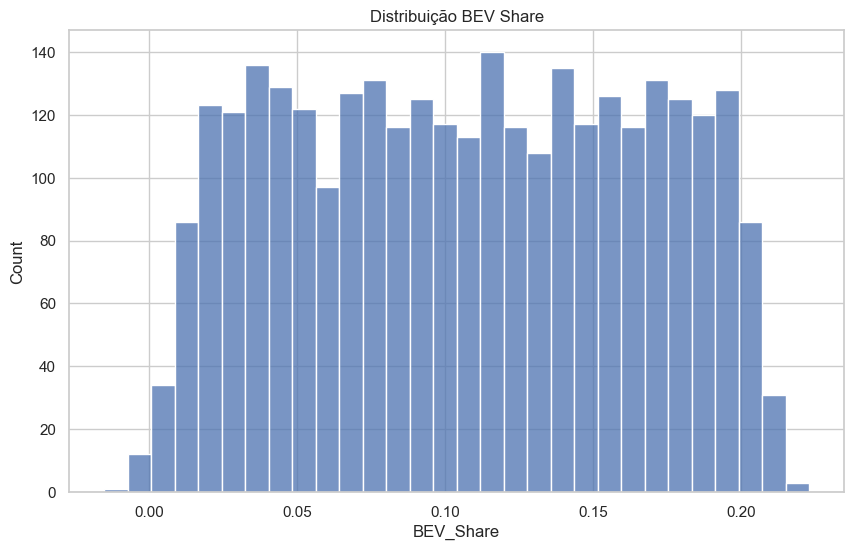

In [7]:
sns.histplot(df["BEV_Share"], bins=30)
plt.title("Distribuição BEV Share")
plt.show()

## Criação da Variável Temporal

In [8]:
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str))
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Date
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0,2018-01-01
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0,2018-01-01
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0,2018-01-01
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0,2018-01-01
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0,2018-01-01


## Evolução Temporal

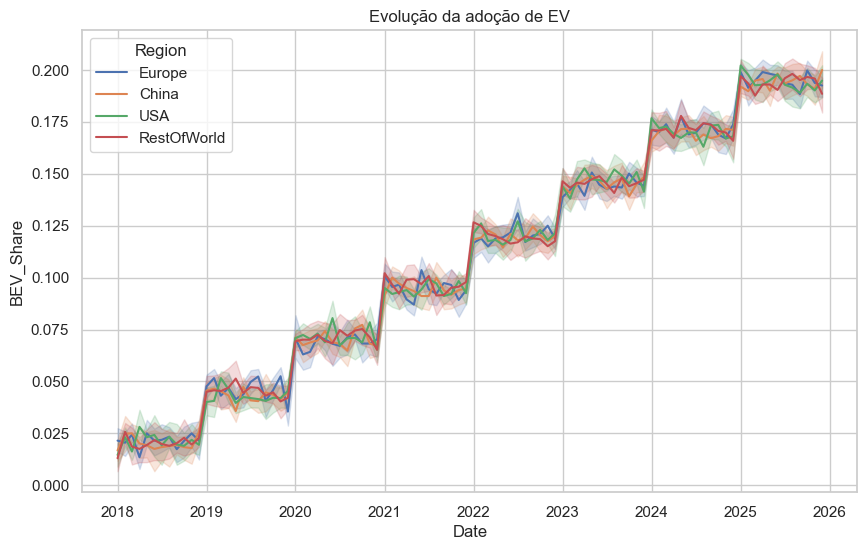

In [9]:
sns.lineplot(data=df, x="Date", y="BEV_Share", hue="Region")
plt.title("Evolução da adoção de EV")
plt.show()

## Criação da Variável Target

In [10]:
df = create_target(df, threshold=0.15)
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Date,High_EV_Adoption
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0,2018-01-01,0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0,2018-01-01,0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0,2018-01-01,0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0,2018-01-01,0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0,2018-01-01,0


## Distribuição do Target

In [11]:
df["High_EV_Adoption"].value_counts()

High_EV_Adoption
0    2178
1     894
Name: count, dtype: int64

In [12]:
df["High_EV_Adoption"].value_counts(normalize=True)

High_EV_Adoption
0    0.708984
1    0.291016
Name: proportion, dtype: float64

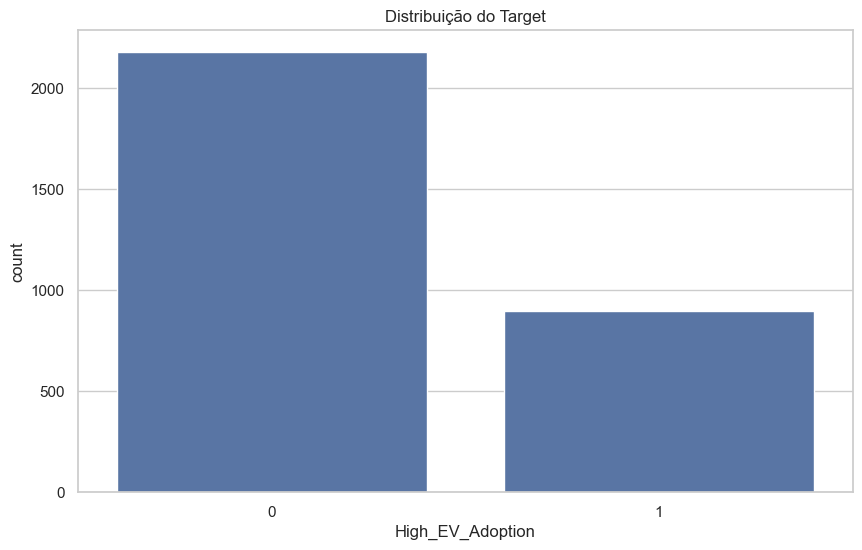

In [13]:
sns.countplot(x="High_EV_Adoption", data=df)
plt.title("Distribuição do Target")
plt.show()

## Comparação entre Classes

In [14]:
df.groupby("High_EV_Adoption").mean(numeric_only=True)

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
High_EV_Adoption,,,,,,,,,
0,2020.359045,6.480257,7732.911387,63826.595960,4.949063e+08,0.078318,14.698499,3.060882,1.119913
1,2024.279642,6.548098,8582.957494,63922.692394,5.515809e+08,0.178842,14.567013,3.049351,1.313412


## Comparação de Features

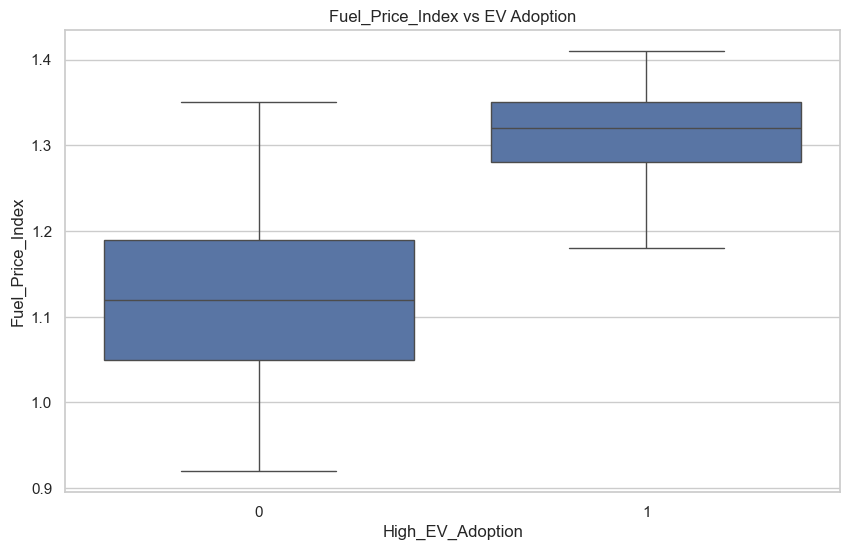

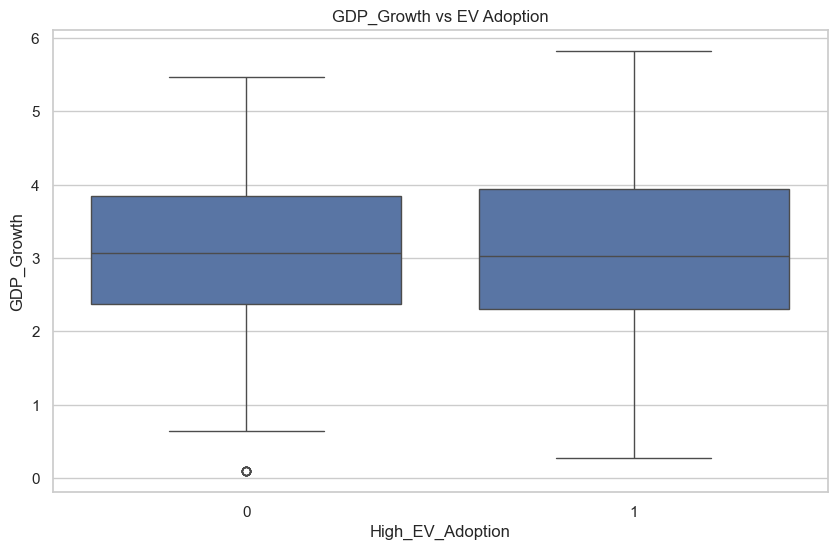

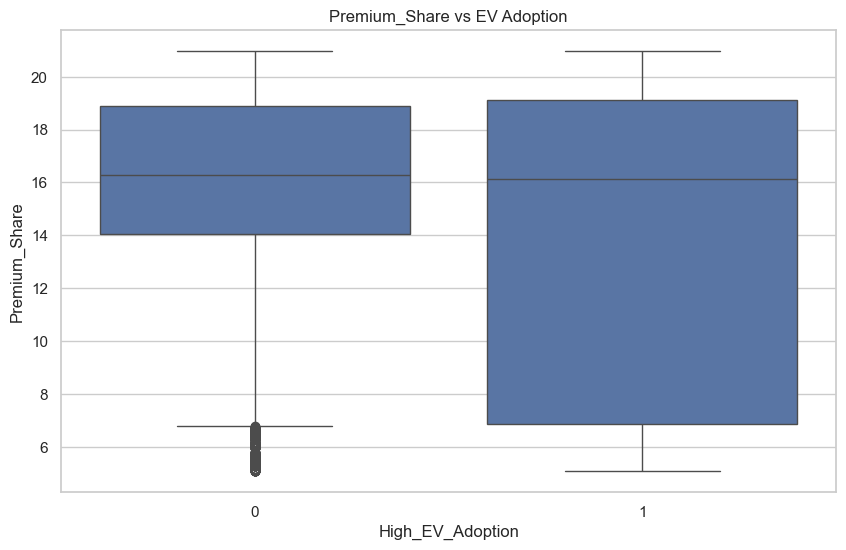

In [15]:
features = ["Fuel_Price_Index", "GDP_Growth", "Premium_Share"]

for col in features:
    sns.boxplot(x="High_EV_Adoption", y=col, data=df)
    plt.title(f"{col} vs EV Adoption")
    plt.show()

## Correlação

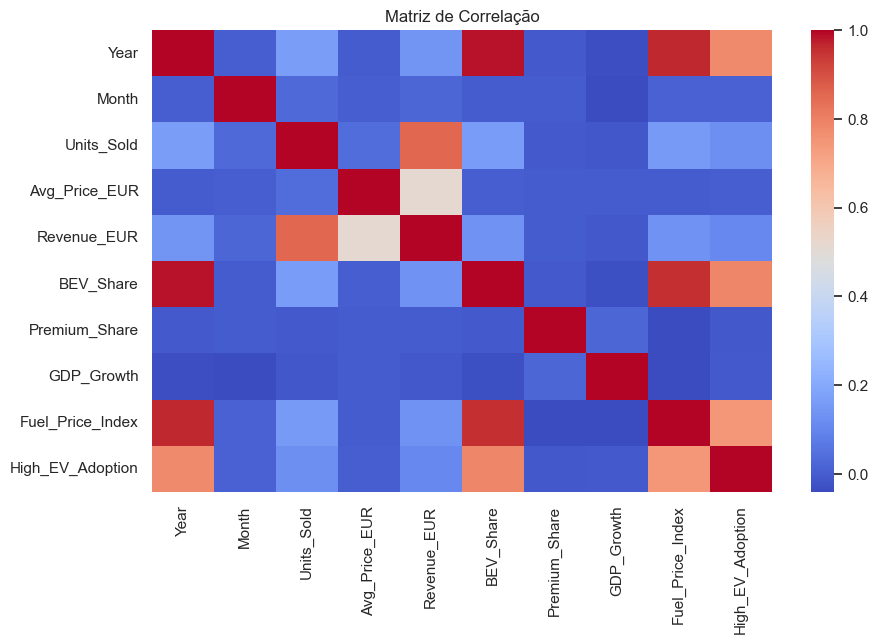

In [16]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

## Análise por Região

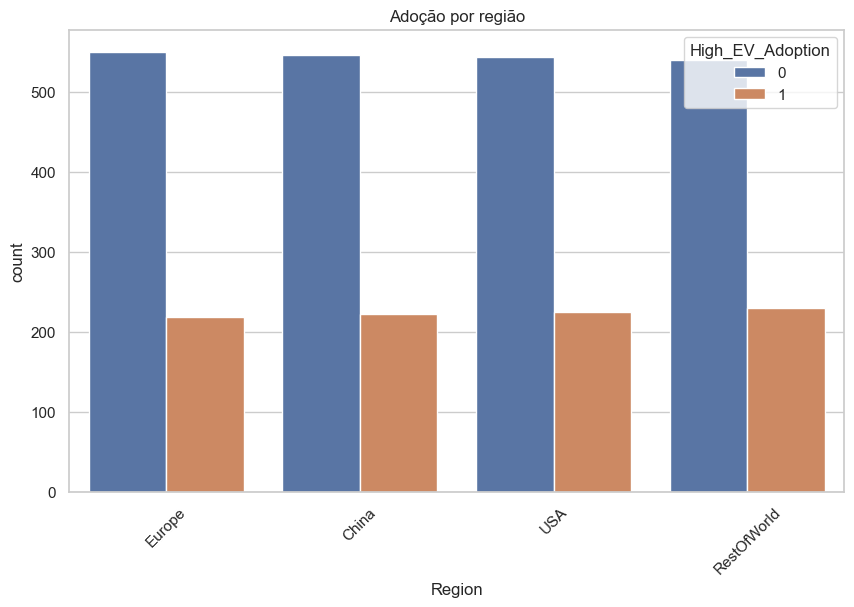

In [17]:
sns.countplot(x="Region", hue="High_EV_Adoption", data=df)
plt.xticks(rotation=45)
plt.title("Adoção por região")
plt.show()

## Conclusões da EDA

- Dataset balanceado (~70/30)
- Variáveis econômicas influenciam a adoção
- Existe tendência temporal
- Diferenças regionais relevantes

Dataset pronto para Feature Engineering.


## Salvando Dataset Processado

In [18]:
df.to_csv("../data/processed/ev_adoption_processed.csv", index=False)